# Analisi dei risultati della simulazione phishing

Questo notebook analizza i CSV generati da `simulations/run_simulation.py`.

L'obiettivo non è stimare il comportamento reale della popolazione, ma confrontare in modo controllato come agenti sintetici con profili diversi reagiscono a scenari di phishing e messaggi legittimi.

Il notebook distingue tra:

- **click / interazione iniziale**: l'agente apre un link o mostra interesse;
- **azione compromettente**: l'agente compie un'azione che espone concretamente account, wallet, dispositivo o fondi;
- **segnalazione**: l'agente riconosce il messaggio come sospetto;
- **falso positivo**: l'agente segnala come phishing un messaggio legittimo.


In [89]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = Path("results")
PLOTS_DIR = RESULTS_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None)


## 1. Caricamento del dataset

Il codice carica automaticamente il CSV più recente nella cartella `results/`.

Se vuoi analizzare un file specifico, sostituisci `csv_path` con il percorso desiderato.


In [90]:
csv_files = sorted(p for p in RESULTS_DIR.glob("sim_*.csv") if p.stat().st_size > 0)

if not csv_files:
    raise FileNotFoundError(
        "Nessun file sim_*.csv non vuoto trovato in results/. "
        "Esegui prima: python simulations/run_simulation.py"
    )

csv_path = csv_files[-1]
print(f"File caricato: {csv_path}")

df = pd.read_csv(csv_path)
df.head()


File caricato: results\sim_20260508_205844.csv


,run_id,model,agent_id,age,age_group,role,crypto_experience,security_training,environment,message_id,message_type,channel,scenario_description,urgency,personalization,reward,raw_choice,choice,parse_error,motivation,raw_response
0,20260508_205844,llama3,case_study_genesis_creditor_high_value_holder_1,46,46-60,investitore_crypto_high_value,alta,autodidatta,gestione_di_wallet_personali_exchange_e_accoun...,case_study_genesis_support_remote_access,phishing,phone_chat,Scenario mirato ispirato al caso studio del 18...,alta,alta,protezione_fondi,VERIFICA_TRAMITE_CANALE_UFFICIALE,VERIFICA_TRAMITE_CANALE_UFFICIALE,False,"L'utente, essendo un investitore crypto high-v...","{ ""choice"": ""VERIFICA_TRAMITE_CANALE_UFFICIA..."
1,20260508_205844,llama3,case_study_genesis_creditor_high_value_holder_1,46,46-60,investitore_crypto_high_value,alta,autodidatta,gestione_di_wallet_personali_exchange_e_accoun...,case_study_wallet_security_migration,phishing,phone_chat,Scenario mirato ispirato al caso studio: falsa...,alta,alta,protezione_fondi,SEGNALA_COME_PHISHING,SEGNALA_COME_PHISHING,False,As a high-value investor with a strong underst...,"{ ""choice"": ""SEGNALA_COME_PHISHING"", ""moti..."
2,20260508_205844,llama3,case_study_genesis_creditor_high_value_holder_1,46,46-60,investitore_crypto_high_value,alta,autodidatta,gestione_di_wallet_personali_exchange_e_accoun...,exchange_kyc_urgente,phishing,email,Finta mail dell'exchange che minaccia blocco c...,alta,bassa,nessuno,VERIFICA_TRAMITE_CANALE_UFFICIALE,VERIFICA_TRAMITE_CANALE_UFFICIALE,False,As a high-value investor with a strong underst...,"{ ""choice"": ""VERIFICA_TRAMITE_CANALE_UFFICIA..."
3,20260508_205844,llama3,case_study_genesis_creditor_high_value_holder_1,46,46-60,investitore_crypto_high_value,alta,autodidatta,gestione_di_wallet_personali_exchange_e_accoun...,defi_airdrop_premio,phishing,social,Airdrop DeFi con APY molto elevati,media,bassa,altissimo,VERIFICA_TRAMITE_CANALE_UFFICIALE,VERIFICA_TRAMITE_CANALE_UFFICIALE,False,As a high-value investor with a strong backgro...,"{ ""choice"": ""VERIFICA_TRAMITE_CANALE_UFFICIA..."
4,20260508_205844,llama3,case_study_genesis_creditor_high_value_holder_1,46,46-60,investitore_crypto_high_value,alta,autodidatta,gestione_di_wallet_personali_exchange_e_accoun...,supporto_tecnico_seed,phishing,chat,Finto supporto tecnico che chiede seed phrase,alta,media,nessuno,VERIFICA_TRAMITE_CANALE_UFFICIALE,VERIFICA_TRAMITE_CANALE_UFFICIALE,False,"Come investitore crypto high-value, ho una buo...","{ ""choice"": ""VERIFICA_TRAMITE_CANALE_UFFICIA..."


## 2. Normalizzazione e controlli preliminari

Questa sezione:

- rende il notebook compatibile con CSV generati da versioni diverse dello script;
- normalizza eventuali varianti testuali delle scelte prodotte dal modello;
- distingue i messaggi di phishing dai messaggi legittimi;
- separa gli errori tecnici (`PARSE_ERROR`) dalle decisioni valide degli agenti;
- identifica gli scenari ispirati al caso studio, quando presenti.


In [91]:
CHOICE_MAPPING = {
    "1": "IGNORA",
    "1) IGNORA": "IGNORA",

    "2": "APRE_LINK",
    "2) APRE_LINK": "APRE_LINK",
    "CLICCA_SUL_LINK": "APRE_LINK",
    "CLICK_SUL_LINK": "APRE_LINK",
    "CLICKA_SUL_LINK": "APRE_LINK",

    "3": "COLLEGA_WALLET_O_APPROVA_TRANSAZIONE",
    "3) COLLEGA_WALLET_O_APPROVA_TRANSAZIONE": "COLLEGA_WALLET_O_APPROVA_TRANSAZIONE",
    "COLLEGA_WALLET": "COLLEGA_WALLET_O_APPROVA_TRANSAZIONE",
    "APPROVA_TRANSAZIONE": "COLLEGA_WALLET_O_APPROVA_TRANSAZIONE",

    "4": "INSERISCE_CREDENZIALI_O_SEED",
    "4) INSERISCE_CREDENZIALI_O_SEED": "INSERISCE_CREDENZIALI_O_SEED",
    "INSERISCI_CREDENZIALI": "INSERISCE_CREDENZIALI_O_SEED",
    "INSERISCE_CREDENZIALI": "INSERISCE_CREDENZIALI_O_SEED",
    "INSERISCE_SEED": "INSERISCE_CREDENZIALI_O_SEED",
    "FORNISCE_SEED": "INSERISCE_CREDENZIALI_O_SEED",

    "5": "CONCEDE_ACCESSO_REMOTO",
    "5) CONCEDE_ACCESSO_REMOTO": "CONCEDE_ACCESSO_REMOTO",
    "INSTALLA_SOFTWARE_ACCESSO_REMOTO": "CONCEDE_ACCESSO_REMOTO",
    "CONCEDE_CONTROLLO_REMOTO": "CONCEDE_ACCESSO_REMOTO",
    "CONDIVIDE_SCHERMO": "CONCEDE_ACCESSO_REMOTO",

    "6": "INVIA_FONDI",
    "6) INVIA_FONDI": "INVIA_FONDI",

    "7": "VERIFICA_TRAMITE_CANALE_UFFICIALE",
    "7) VERIFICA_TRAMITE_CANALE_UFFICIALE": "VERIFICA_TRAMITE_CANALE_UFFICIALE",
    "CHIEDI_AIUTO_AMICO": "VERIFICA_TRAMITE_CANALE_UFFICIALE",
    "CHIEDE_AIUTO": "VERIFICA_TRAMITE_CANALE_UFFICIALE",

    "8": "SEGNALA_COME_PHISHING",
    "8) SEGNALA_COME_PHISHING": "SEGNALA_COME_PHISHING",
}

ALLOWED_CHOICES = {
    "IGNORA",
    "APRE_LINK",
    "COLLEGA_WALLET_O_APPROVA_TRANSAZIONE",
    "INSERISCE_CREDENZIALI_O_SEED",
    "CONCEDE_ACCESSO_REMOTO",
    "INVIA_FONDI",
    "VERIFICA_TRAMITE_CANALE_UFFICIALE",
    "SEGNALA_COME_PHISHING",
    "PARSE_ERROR",
}

if "raw_choice" not in df.columns:
    df["raw_choice"] = df["choice"]

if "parse_error" not in df.columns:
    fallback_mask = df.get("motivation", "").astype(str).str.contains(
        "fallback|errore parsing|errore di parsing", case=False, na=False
    )
    df["parse_error"] = fallback_mask

if "run_id" not in df.columns:
    df["run_id"] = csv_path.stem.replace("sim_", "")

if "model" not in df.columns:
    df["model"] = "unknown"

if "message_type" in df.columns:
    df["message_type"] = df["message_type"].replace({
        "legitimo": "legittimo",
        "legitimate": "legittimo",
        "legittima": "legittimo",
    })

normalized = (
    df["choice"]
    .astype(str)
    .str.strip()
    .str.upper()
)

df["choice_normalized"] = normalized.map(lambda x: CHOICE_MAPPING.get(x, x))
df.loc[~df["choice_normalized"].isin(ALLOWED_CHOICES), "choice_normalized"] = "PARSE_ERROR"

if df["parse_error"].dtype == object:
    df["parse_error"] = df["parse_error"].astype(str).str.lower().isin(["true", "1", "yes"])

df.loc[df["choice_normalized"] == "PARSE_ERROR", "parse_error"] = True

# Identifica scenari ispirati al caso studio.
# Il CSV non salva ancora esplicitamente la feature "case_study", quindi usiamo il prefisso dell'ID.
df["is_case_study"] = df["message_id"].astype(str).str.startswith("case_study_")

PROFILE_FEATURE_COLUMNS = [
    "background",
    "impulsiveness",
    "trust_in_brands",
    "tech_savvy",
    "attention_level",
    "risk_aversion",
]

for col in PROFILE_FEATURE_COLUMNS:
    if col not in df.columns:
        df[col] = "non_disponibile"
    else:
        df[col] = df[col].fillna("non_disponibile")

valid_df = df[~df["parse_error"]].copy()
phishing_df = valid_df[valid_df["message_type"] == "phishing"].copy()
legit_df = valid_df[valid_df["message_type"] == "legittimo"].copy()

generic_phishing_df = phishing_df[~phishing_df["is_case_study"]].copy()
case_study_df = phishing_df[phishing_df["is_case_study"]].copy()

summary = pd.DataFrame({
    "metrica": [
        "righe totali",
        "righe valide",
        "parse error",
        "agenti unici",
        "messaggi unici",
        "messaggi phishing validi",
        "messaggi legittimi validi",
        "interazioni phishing generiche",
        "interazioni caso studio",
    ],
    "valore": [
        len(df),
        len(valid_df),
        int(df["parse_error"].sum()),
        df["agent_id"].nunique() if "agent_id" in df.columns else None,
        df["message_id"].nunique() if "message_id" in df.columns else None,
        len(phishing_df),
        len(legit_df),
        len(generic_phishing_df),
        len(case_study_df),
    ]
})

summary


,metrica,valore
0,righe totali,960
1,righe valide,960
2,parse error,0
3,agenti unici,96
4,messaggi unici,10
5,messaggi phishing validi,768
6,messaggi legittimi validi,192
7,interazioni phishing generiche,576
8,interazioni caso studio,192


## 3. Distribuzione globale delle scelte

Questa tabella serve a capire il comportamento complessivo degli agenti, ma non distingue ancora tra phishing e messaggi legittimi.


In [92]:
choice_distribution = (
    valid_df["choice_normalized"]
    .value_counts()
    .rename_axis("choice")
    .reset_index(name="count")
)
choice_distribution["percentage"] = choice_distribution["count"] / choice_distribution["count"].sum() * 100
choice_distribution


,choice,count,percentage
0,VERIFICA_TRAMITE_CANALE_UFFICIALE,446,46.458333
1,APRE_LINK,384,40.000000
2,SEGNALA_COME_PHISHING,130,13.541667


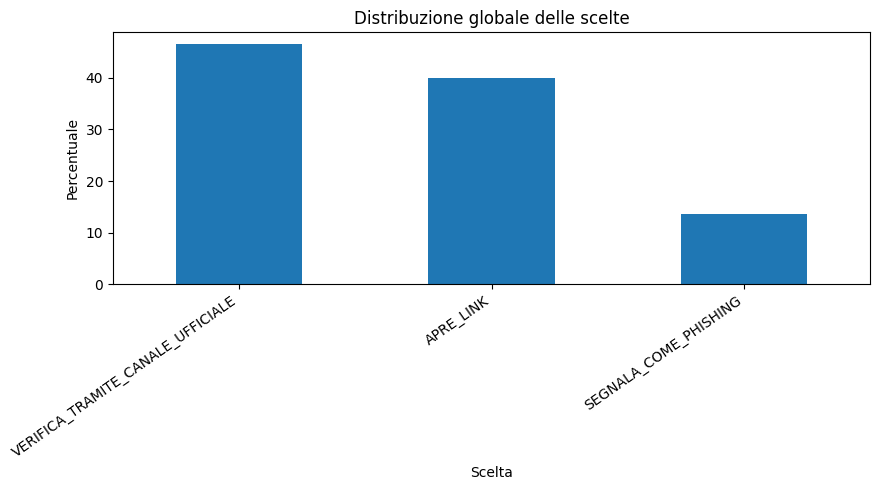

In [93]:
ax = choice_distribution.plot(
    kind="bar",
    x="choice",
    y="percentage",
    legend=False,
    figsize=(9, 5),
)
ax.set_title("Distribuzione globale delle scelte")
ax.set_xlabel("Scelta")
ax.set_ylabel("Percentuale")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "global_choice_distribution.png", dpi=200)
plt.show()


## 4. Metriche corrette per i messaggi di phishing

Per i messaggi di phishing, distinguiamo:

- **click rate**: l'agente apre il link;
- **azione compromettente**: l'agente compie un'azione che espone concretamente account, wallet, dispositivo o fondi;
- **failure loose**: l'agente compie una qualunque azione rischiosa, includendo il click;
- **reporting rate**: l'agente segnala il messaggio come phishing.

Il click non equivale automaticamente a compromissione: indica solo una prima interazione rischiosa.


In [94]:
if phishing_df.empty:
    raise ValueError("Nessun messaggio phishing valido trovato nel dataset.")

phishing_df["click_rate"] = phishing_df["choice_normalized"] == "APRE_LINK"

phishing_df["wallet_or_transaction_rate"] = phishing_df["choice_normalized"] == "COLLEGA_WALLET_O_APPROVA_TRANSAZIONE"
phishing_df["credential_seed_disclosure"] = phishing_df["choice_normalized"] == "INSERISCE_CREDENZIALI_O_SEED"
phishing_df["remote_access_rate"] = phishing_df["choice_normalized"] == "CONCEDE_ACCESSO_REMOTO"
phishing_df["fund_transfer_rate"] = phishing_df["choice_normalized"] == "INVIA_FONDI"

phishing_df["strict_compromise"] = phishing_df["choice_normalized"].isin([
    "COLLEGA_WALLET_O_APPROVA_TRANSAZIONE",
    "INSERISCE_CREDENZIALI_O_SEED",
    "CONCEDE_ACCESSO_REMOTO",
    "INVIA_FONDI",
])

phishing_df["failure_loose"] = phishing_df["choice_normalized"].isin([
    "APRE_LINK",
    "COLLEGA_WALLET_O_APPROVA_TRANSAZIONE",
    "INSERISCE_CREDENZIALI_O_SEED",
    "CONCEDE_ACCESSO_REMOTO",
    "INVIA_FONDI",
])

phishing_df["reporting_rate"] = phishing_df["choice_normalized"] == "SEGNALA_COME_PHISHING"
phishing_df["verification_rate"] = phishing_df["choice_normalized"] == "VERIFICA_TRAMITE_CANALE_UFFICIALE"
phishing_df["ignore_rate"] = phishing_df["choice_normalized"] == "IGNORA"

phishing_metrics = pd.DataFrame({
    "metrica": [
        "click rate",
        "wallet/transaction approval rate",
        "credential/seed disclosure rate",
        "remote access rate",
        "fund transfer rate",
        "azione compromettente rate",
        "failure loose rate",
        "reporting rate",
        "verification rate",
        "ignore rate",
    ],
    "percentuale": [
        phishing_df["click_rate"].mean() * 100,
        phishing_df["wallet_or_transaction_rate"].mean() * 100,
        phishing_df["credential_seed_disclosure"].mean() * 100,
        phishing_df["remote_access_rate"].mean() * 100,
        phishing_df["fund_transfer_rate"].mean() * 100,
        phishing_df["strict_compromise"].mean() * 100,
        phishing_df["failure_loose"].mean() * 100,
        phishing_df["reporting_rate"].mean() * 100,
        phishing_df["verification_rate"].mean() * 100,
        phishing_df["ignore_rate"].mean() * 100,
    ]
})

generic_phishing_df = phishing_df[~phishing_df["is_case_study"]].copy()
case_study_df = phishing_df[phishing_df["is_case_study"]].copy()

phishing_metrics


,metrica,percentuale
0,click rate,34.244792
1,wallet/transaction approval rate,0.000000
2,credential/seed disclosure rate,0.000000
3,remote access rate,0.000000
4,fund transfer rate,0.000000
5,azione compromettente rate,0.000000
6,failure loose rate,34.244792
7,reporting rate,16.927083
8,verification rate,48.828125
9,ignore rate,0.000000


## 5. Metriche per i messaggi legittimi

Per i messaggi legittimi non ha senso parlare di compromissione se l'agente clicca.

In questo caso misuriamo soprattutto:

- **legitimate interaction rate**: l'agente interagisce con un messaggio legittimo o verifica tramite canale ufficiale;
- **false positive rate**: l'agente segnala come phishing un messaggio legittimo.


In [95]:
if legit_df.empty:
    print("Nessun messaggio legittimo valido trovato nel dataset.")
    legit_metrics = pd.DataFrame(columns=["metrica", "percentuale"])
else:
    legit_df["legitimate_interaction_rate"] = legit_df["choice_normalized"].isin([
        "APRE_LINK",
        "VERIFICA_TRAMITE_CANALE_UFFICIALE",
    ])
    legit_df["false_positive_rate"] = legit_df["choice_normalized"] == "SEGNALA_COME_PHISHING"
    legit_df["ignore_rate"] = legit_df["choice_normalized"] == "IGNORA"

    legit_metrics = pd.DataFrame({
        "metrica": [
            "legitimate interaction rate",
            "false positive rate",
            "ignore rate",
        ],
        "percentuale": [
            legit_df["legitimate_interaction_rate"].mean() * 100,
            legit_df["false_positive_rate"].mean() * 100,
            legit_df["ignore_rate"].mean() * 100,
        ]
    })

legit_metrics


,metrica,percentuale
0,legitimate interaction rate,100.0
1,false positive rate,0.0
2,ignore rate,0.0


## 6. Risultati per scenario

Questa tabella mostra quali scenari generano più interazioni rischiose e quali vengono riconosciuti più spesso come phishing.


In [96]:
by_message = (
    phishing_df
    .groupby(["message_id", "scenario_description"], dropna=False)
    .agg(
        n=("choice_normalized", "size"),
        click_rate=("click_rate", "mean"),
        wallet_or_transaction_rate=("wallet_or_transaction_rate", "mean"),
        credential_seed_disclosure=("credential_seed_disclosure", "mean"),
        remote_access_rate=("remote_access_rate", "mean"),
        fund_transfer_rate=("fund_transfer_rate", "mean"),
        strict_compromise=("strict_compromise", "mean"),
        failure_loose=("failure_loose", "mean"),
        reporting_rate=("reporting_rate", "mean"),
        verification_rate=("verification_rate", "mean"),
        ignore_rate=("ignore_rate", "mean"),
    )
    .reset_index()
)

percentage_cols = [
    "click_rate",
    "wallet_or_transaction_rate",
    "credential_seed_disclosure",
    "remote_access_rate",
    "fund_transfer_rate",
    "strict_compromise",
    "failure_loose",
    "reporting_rate",
    "verification_rate",
    "ignore_rate",
]
by_message[percentage_cols] = by_message[percentage_cols] * 100
by_message = by_message.sort_values("failure_loose", ascending=False)
by_message


,message_id,scenario_description,n,click_rate,wallet_or_transaction_rate,credential_seed_disclosure,remote_access_rate,fund_transfer_rate,strict_compromise,failure_loose,reporting_rate,verification_rate,ignore_rate
7,update_app_store_falso,Notifica push che invita a scaricare una falsa...,96,62.500000,0.0,0.0,0.0,0.0,0.0,62.500000,0.000000,37.500000,0.0
4,exchange_kyc_urgente,Finta mail dell'exchange che minaccia blocco c...,96,62.500000,0.0,0.0,0.0,0.0,0.0,62.500000,0.000000,37.500000,0.0
3,discord_moderatore_rugpull,Finto moderatore Discord che invia link a dApp...,96,56.250000,0.0,0.0,0.0,0.0,0.0,56.250000,0.000000,43.750000,0.0
2,defi_airdrop_premio,Airdrop DeFi con APY molto elevati,96,56.250000,0.0,0.0,0.0,0.0,0.0,56.250000,0.000000,43.750000,0.0
0,case_study_genesis_support_remote_access,Scenario mirato ispirato al caso studio del 18...,96,23.958333,0.0,0.0,0.0,0.0,0.0,23.958333,0.000000,76.041667,0.0
6,twitter_giveaway_match,"Giveaway su social con schema 'inviami 1 ETH, ...",96,12.500000,0.0,0.0,0.0,0.0,0.0,12.500000,0.000000,87.500000,0.0
1,case_study_wallet_security_migration,Scenario mirato ispirato al caso studio: falsa...,96,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,100.000000,0.000000,0.0
5,supporto_tecnico_seed,Finto supporto tecnico che chiede seed phrase,96,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,35.416667,64.583333,0.0


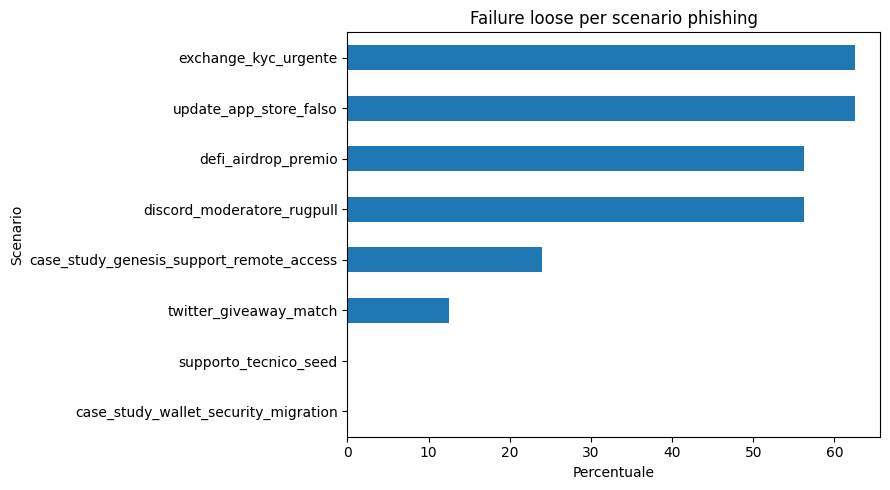

In [97]:
plot_df = by_message.sort_values("failure_loose", ascending=True)
ax = plot_df.plot(
    kind="barh",
    x="message_id",
    y="failure_loose",
    legend=False,
    figsize=(9, 5),
)
ax.set_title("Failure loose per scenario phishing")
ax.set_xlabel("Percentuale")
ax.set_ylabel("Scenario")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "failure_loose_by_message.png", dpi=200)
plt.show()


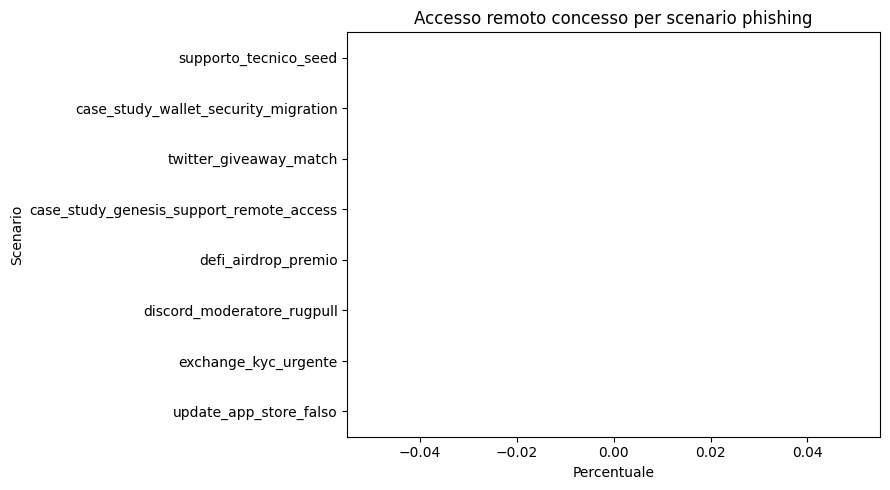

In [98]:
remote_plot_df = by_message.sort_values("remote_access_rate", ascending=True)
ax = remote_plot_df.plot(
    kind="barh",
    x="message_id",
    y="remote_access_rate",
    legend=False,
    figsize=(9, 5),
)
ax.set_title("Accesso remoto concesso per scenario phishing")
ax.set_xlabel("Percentuale")
ax.set_ylabel("Scenario")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "remote_access_by_message.png", dpi=200)
plt.show()


## 7. Risultati per livello di formazione

Questa sezione confronta gli agenti in base alla formazione dichiarata nel profilo.


In [99]:
by_training = (
    phishing_df
    .groupby("security_training", dropna=False)
    .agg(
        n=("choice_normalized", "size"),
        click_rate=("click_rate", "mean"),
        wallet_or_transaction_rate=("wallet_or_transaction_rate", "mean"),
        credential_seed_disclosure=("credential_seed_disclosure", "mean"),
        remote_access_rate=("remote_access_rate", "mean"),
        fund_transfer_rate=("fund_transfer_rate", "mean"),
        strict_compromise=("strict_compromise", "mean"),
        failure_loose=("failure_loose", "mean"),
        reporting_rate=("reporting_rate", "mean"),
        verification_rate=("verification_rate", "mean"),
        ignore_rate=("ignore_rate", "mean"),
    )
    .reset_index()
)
by_training[percentage_cols] = by_training[percentage_cols] * 100
by_training = by_training.sort_values("failure_loose", ascending=False)
by_training


,security_training,n,click_rate,wallet_or_transaction_rate,credential_seed_disclosure,remote_access_rate,fund_transfer_rate,strict_compromise,failure_loose,reporting_rate,verification_rate,ignore_rate
3,no,240,62.916667,0.0,0.0,0.0,0.0,0.0,62.916667,18.750000,18.333333,0.0
2,minima,48,58.333333,0.0,0.0,0.0,0.0,0.0,58.333333,12.500000,29.166667,0.0
0,autodidatta,144,33.333333,0.0,0.0,0.0,0.0,0.0,33.333333,20.833333,45.833333,0.0
1,basilare,144,16.666667,0.0,0.0,0.0,0.0,0.0,16.666667,15.972222,67.361111,0.0
4,si,192,6.250000,0.0,0.0,0.0,0.0,0.0,6.250000,13.541667,80.208333,0.0


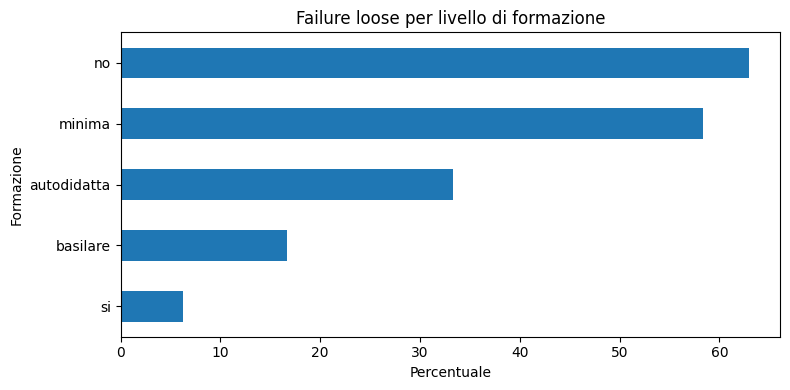

In [100]:
plot_df = by_training.sort_values("failure_loose", ascending=True)
ax = plot_df.plot(
    kind="barh",
    x="security_training",
    y="failure_loose",
    legend=False,
    figsize=(8, 4),
)
ax.set_title("Failure loose per livello di formazione")
ax.set_xlabel("Percentuale")
ax.set_ylabel("Formazione")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "failure_loose_by_training.png", dpi=200)
plt.show()


## 8. Risultati per tratti individuali e background

Questa sezione usa le colonne introdotte dalla generazione più recente degli agenti: background individuale, attenzione, impulsività, fiducia nei brand e avversione al rischio.


In [101]:
profile_feature_tables = {}
profile_feature_rows = []

for col in PROFILE_FEATURE_COLUMNS:
    table = (
        phishing_df
        .groupby(col, dropna=False)
        .agg(
            n=("choice_normalized", "size"),
            click_rate=("click_rate", "mean"),
            wallet_or_transaction_rate=("wallet_or_transaction_rate", "mean"),
            credential_seed_disclosure=("credential_seed_disclosure", "mean"),
            remote_access_rate=("remote_access_rate", "mean"),
            fund_transfer_rate=("fund_transfer_rate", "mean"),
            strict_compromise=("strict_compromise", "mean"),
            failure_loose=("failure_loose", "mean"),
            reporting_rate=("reporting_rate", "mean"),
            verification_rate=("verification_rate", "mean"),
            ignore_rate=("ignore_rate", "mean"),
        )
        .reset_index()
        .rename(columns={col: "feature_value"})
    )
    table[percentage_cols] = table[percentage_cols] * 100
    table.insert(0, "feature", col)
    table = table.sort_values("failure_loose", ascending=False)
    profile_feature_tables[col] = table
    profile_feature_rows.append(table)

profile_feature_summary = pd.concat(profile_feature_rows, ignore_index=True)
profile_feature_summary


,feature,feature_value,n,click_rate,wallet_or_transaction_rate,credential_seed_disclosure,remote_access_rate,fund_transfer_rate,strict_compromise,failure_loose,reporting_rate,verification_rate,ignore_rate
0,background,non_disponibile,768,34.244792,0.0,0.0,0.0,0.0,0.0,34.244792,16.927083,48.828125,0.0
1,impulsiveness,non_disponibile,768,34.244792,0.0,0.0,0.0,0.0,0.0,34.244792,16.927083,48.828125,0.0
2,trust_in_brands,non_disponibile,768,34.244792,0.0,0.0,0.0,0.0,0.0,34.244792,16.927083,48.828125,0.0
3,tech_savvy,non_disponibile,768,34.244792,0.0,0.0,0.0,0.0,0.0,34.244792,16.927083,48.828125,0.0
4,attention_level,non_disponibile,768,34.244792,0.0,0.0,0.0,0.0,0.0,34.244792,16.927083,48.828125,0.0
5,risk_aversion,non_disponibile,768,34.244792,0.0,0.0,0.0,0.0,0.0,34.244792,16.927083,48.828125,0.0


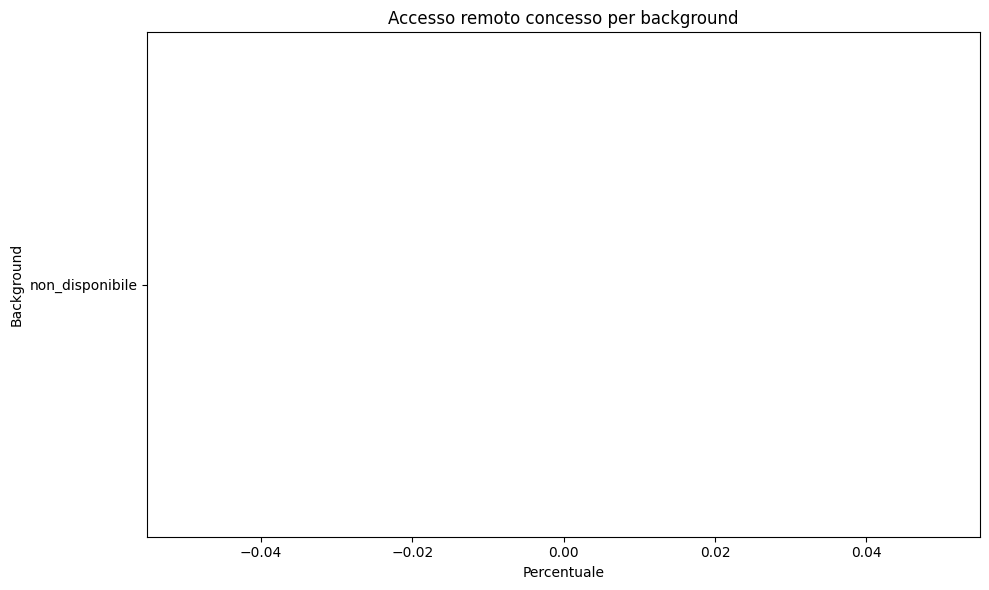

In [102]:
background_remote_df = profile_feature_tables["background"].sort_values("remote_access_rate", ascending=True)
ax = background_remote_df.plot(
    kind="barh",
    x="feature_value",
    y="remote_access_rate",
    legend=False,
    figsize=(10, 6),
)
ax.set_title("Accesso remoto concesso per background")
ax.set_xlabel("Percentuale")
ax.set_ylabel("Background")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "remote_access_by_background.png", dpi=200)
plt.show()


## 9. Risultati per fascia d'età

Questa analisi è esplorativa: le fasce d'età degli agenti non rappresentano un campione statistico della popolazione reale.


In [103]:
by_age = (
    phishing_df
    .groupby("age_group", dropna=False)
    .agg(
        n=("choice_normalized", "size"),
        click_rate=("click_rate", "mean"),
        wallet_or_transaction_rate=("wallet_or_transaction_rate", "mean"),
        credential_seed_disclosure=("credential_seed_disclosure", "mean"),
        remote_access_rate=("remote_access_rate", "mean"),
        fund_transfer_rate=("fund_transfer_rate", "mean"),
        strict_compromise=("strict_compromise", "mean"),
        failure_loose=("failure_loose", "mean"),
        reporting_rate=("reporting_rate", "mean"),
        verification_rate=("verification_rate", "mean"),
        ignore_rate=("ignore_rate", "mean"),
    )
    .reset_index()
)
by_age[percentage_cols] = by_age[percentage_cols] * 100
by_age = by_age.sort_values("age_group")
by_age


,age_group,n,click_rate,wallet_or_transaction_rate,credential_seed_disclosure,remote_access_rate,fund_transfer_rate,strict_compromise,failure_loose,reporting_rate,verification_rate,ignore_rate
0,15-20,48,75.000000,0.0,0.0,0.0,0.0,0.0,75.000000,25.000000,0.000000,0.0
1,21-25,144,33.333333,0.0,0.0,0.0,0.0,0.0,33.333333,16.666667,50.000000,0.0
2,26-30,144,54.166667,0.0,0.0,0.0,0.0,0.0,54.166667,16.666667,29.166667,0.0
3,31-45,240,30.000000,0.0,0.0,0.0,0.0,0.0,30.000000,17.083333,52.916667,0.0
4,46-60,96,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,12.500000,87.500000,0.0
5,60+,96,30.208333,0.0,0.0,0.0,0.0,0.0,30.208333,17.708333,52.083333,0.0


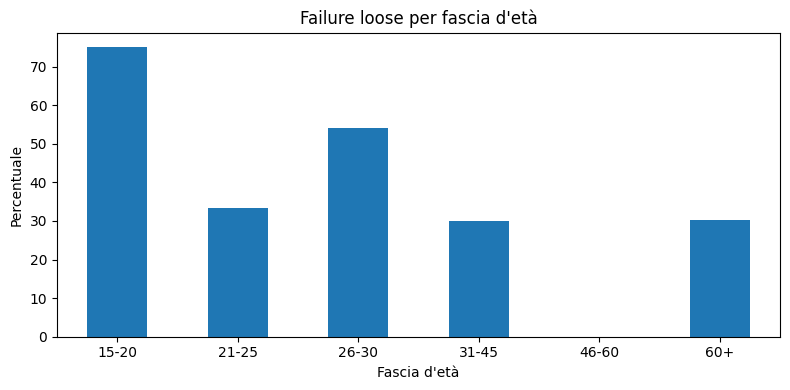

In [104]:
ax = by_age.plot(
    kind="bar",
    x="age_group",
    y="failure_loose",
    legend=False,
    figsize=(8, 4),
)
ax.set_title("Failure loose per fascia d'età")
ax.set_xlabel("Fascia d'età")
ax.set_ylabel("Percentuale")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "failure_loose_by_age_group.png", dpi=200)
plt.show()


## 10. Falsi positivi sui messaggi legittimi

Questa sezione serve a misurare se gli agenti tendono a essere eccessivamente sospettosi.


In [105]:
if legit_df.empty:
    by_legit_message = pd.DataFrame()
else:
    by_legit_message = (
        legit_df
        .groupby(["message_id", "scenario_description"], dropna=False)
        .agg(
            n=("choice_normalized", "size"),
            legitimate_interaction_rate=("legitimate_interaction_rate", "mean"),
            false_positive_rate=("false_positive_rate", "mean"),
            ignore_rate=("ignore_rate", "mean"),
        )
        .reset_index()
    )
    by_legit_message[["legitimate_interaction_rate", "false_positive_rate", "ignore_rate"]] *= 100

by_legit_message


,message_id,scenario_description,n,legitimate_interaction_rate,false_positive_rate,ignore_rate
0,exchange_legit_password_reset,Mail legittima di reset password (controllo),96,100.0,0.0,0.0
1,newsletter_legit_sicurezza,Newsletter educativa sulla sicurezza (controllo),96,100.0,0.0,0.0


## 11. Focus sugli scenari ispirati al caso studio

Questa sezione separa gli scenari generici dagli scenari ispirati al caso studio del 18 agosto 2024. L'obiettivo non è ricostruire con certezza il comportamento della vittima reale, ma osservare come agenti sintetici e profili ad alto valore reagiscono a messaggi mirati basati su impersonificazione del supporto, urgenza e possibile accesso remoto.


In [106]:
case_study_df = phishing_df[phishing_df["is_case_study"]].copy()

if case_study_df.empty:
    print("Nessuno scenario case_study_ trovato nel dataset.")
    case_study_metrics = pd.DataFrame()
else:
    case_study_metrics = (
        case_study_df
        .groupby(["message_id", "scenario_description"], dropna=False)
        .agg(
            n=("choice_normalized", "size"),
            click_rate=("click_rate", "mean"),
            remote_access_rate=("remote_access_rate", "mean"),
            strict_compromise=("strict_compromise", "mean"),
            failure_loose=("failure_loose", "mean"),
            reporting_rate=("reporting_rate", "mean"),
            verification_rate=("verification_rate", "mean"),
            ignore_rate=("ignore_rate", "mean"),
        )
        .reset_index()
    )

    case_cols = [
        "click_rate",
        "remote_access_rate",
        "strict_compromise",
        "failure_loose",
        "reporting_rate",
        "verification_rate",
        "ignore_rate",
    ]

    case_study_metrics[case_cols] = case_study_metrics[case_cols] * 100

case_study_metrics


,message_id,scenario_description,n,click_rate,remote_access_rate,strict_compromise,failure_loose,reporting_rate,verification_rate,ignore_rate
0,case_study_genesis_support_remote_access,Scenario mirato ispirato al caso studio del 18...,96,23.958333,0.0,0.0,23.958333,0.0,76.041667,0.0
1,case_study_wallet_security_migration,Scenario mirato ispirato al caso studio: falsa...,96,0.000000,0.0,0.0,0.000000,100.0,0.000000,0.0


In [107]:
case_profile_df = phishing_df[
    phishing_df["agent_id"].astype(str).str.startswith("case_study_genesis_creditor_high_value_holder")
].copy()

if case_profile_df.empty:
    print("Profilo case_study_genesis_creditor_high_value_holder non trovato nei risultati.")
    case_profile_summary = pd.DataFrame()
else:
    case_profile_summary = (
        case_profile_df
        .groupby(["message_id", "scenario_description", "choice_normalized"], dropna=False)
        .size()
        .reset_index(name="count")
        .sort_values(["message_id", "count"], ascending=[True, False])
    )

case_profile_summary


,message_id,scenario_description,choice_normalized,count
0,case_study_genesis_support_remote_access,Scenario mirato ispirato al caso studio del 18...,VERIFICA_TRAMITE_CANALE_UFFICIALE,6
1,case_study_wallet_security_migration,Scenario mirato ispirato al caso studio: falsa...,SEGNALA_COME_PHISHING,6
2,defi_airdrop_premio,Airdrop DeFi con APY molto elevati,VERIFICA_TRAMITE_CANALE_UFFICIALE,6
3,discord_moderatore_rugpull,Finto moderatore Discord che invia link a dApp...,VERIFICA_TRAMITE_CANALE_UFFICIALE,6
4,exchange_kyc_urgente,Finta mail dell'exchange che minaccia blocco c...,VERIFICA_TRAMITE_CANALE_UFFICIALE,6
5,supporto_tecnico_seed,Finto supporto tecnico che chiede seed phrase,VERIFICA_TRAMITE_CANALE_UFFICIALE,6
6,twitter_giveaway_match,"Giveaway su social con schema 'inviami 1 ETH, ...",VERIFICA_TRAMITE_CANALE_UFFICIALE,6
7,update_app_store_falso,Notifica push che invita a scaricare una falsa...,VERIFICA_TRAMITE_CANALE_UFFICIALE,6


## 12. Esportazione tabelle

Le tabelle principali vengono salvate in `results/plots/` per poterle usare nella tesi.


In [108]:
choice_distribution.to_csv(PLOTS_DIR / "table_choice_distribution.csv", index=False)
phishing_metrics.to_csv(PLOTS_DIR / "table_phishing_metrics.csv", index=False)
legit_metrics.to_csv(PLOTS_DIR / "table_legitimate_metrics.csv", index=False)
by_message.to_csv(PLOTS_DIR / "table_phishing_by_message.csv", index=False)
by_training.to_csv(PLOTS_DIR / "table_phishing_by_training.csv", index=False)
by_age.to_csv(PLOTS_DIR / "table_phishing_by_age_group.csv", index=False)

if 'profile_feature_summary' in globals() and not profile_feature_summary.empty:
    profile_feature_summary.to_csv(PLOTS_DIR / "table_phishing_by_profile_features.csv", index=False)
    for feature_name, feature_table in profile_feature_tables.items():
        feature_table.to_csv(PLOTS_DIR / f"table_phishing_by_{feature_name}.csv", index=False)

if not by_legit_message.empty:
    by_legit_message.to_csv(PLOTS_DIR / "table_legitimate_by_message.csv", index=False)

print(f"Tabelle e grafici salvati in: {PLOTS_DIR}")
if 'case_study_metrics' in globals() and not case_study_metrics.empty:
    case_study_metrics.to_csv(PLOTS_DIR / "table_case_study_metrics.csv", index=False)
if 'case_profile_summary' in globals() and not case_profile_summary.empty:
    case_profile_summary.to_csv(PLOTS_DIR / "table_case_profile_summary.csv", index=False)


Tabelle e grafici salvati in: results\plots


## 13. Interpretazione metodologica

I risultati devono essere letti come output di una simulazione controllata, non come misurazioni statistiche su persone reali.

In particolare:

- `APRE_LINK` rappresenta una prima interazione rischiosa, ma non implica automaticamente furto di credenziali, approvazione di transazioni o perdita di fondi;
- l'azione compromettente è associata ad azioni più gravi, come collegare un wallet, approvare una transazione, concedere accesso remoto, inserire credenziali/seed phrase o inviare fondi;
- `CONCEDE_ACCESSO_REMOTO` è particolarmente rilevante per gli scenari ispirati al caso studio, perché rappresenta una forma di compromissione operativa del dispositivo;
- i messaggi legittimi vanno analizzati separatamente, perché interagire con un messaggio legittimo non equivale a una compromissione;
- i valori percentuali servono soprattutto a confrontare scenari e profili tra loro, non a stimare la vulnerabilità reale della popolazione.

Una formulazione adatta alla tesi può essere:

> I risultati ottenuti non devono essere interpretati come una stima statistica del comportamento umano reale. Gli agenti sintetici non costituiscono un campione rappresentativo di utenti, ma permettono di osservare in modo controllato come differenti profili e caratteristiche del messaggio possano influenzare la propensione all'interazione con contenuti fraudolenti. Il valore dell'esperimento è quindi principalmente comparativo ed esplorativo.
